# SNN Simulation from Scratch

Spiking Neural Network implementation using discrete-time LIF neurons.

In [127]:
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
import pprint

network_path = 'results/best.json'

with open(network_path, 'r') as f:
    network_config = json.load(f)

print(f'Network loaded from: {network_path}')
print(f'Network config:')
pprint.pprint(network_config)

Network loaded from: results/best.json
Network config:
{'Associated_Data': {'application': {'encoder_ticks': 1},
                     'processor': {'Leak_Enable': True,
                                   'Max_Axon_Delay': 0,
                                   'Max_Leak': 4,
                                   'Max_Synapse_Delay': 255,
                                   'Max_Threshold': 127,
                                   'Max_Weight': 127,
                                   'Min_Axon_Delay': 0,
                                   'Min_Leak': -1,
                                   'Min_Synapse_Delay': 0,
                                   'Min_Threshold': 0,
                                   'Min_Weight': -127}},
 'Edges': [{'from': 2, 'to': 1, 'values': [28.0, 224.0]},
           {'from': 0, 'to': 2, 'values': [85.0, 158.0]},
           {'from': 2, 'to': 4, 'values': [-41.0, 75.0]},
           {'from': 2, 'to': 2, 'values': [-112.0, 130.0]},
           {'from': 1, 'to': 4, 'values':

In [128]:
num_neurons = len(network_config.get('Nodes', []))
num_synapses = len(network_config.get('Edges', []))

print(f'Network: {num_neurons} neurons, {num_synapses} synapses')

Network: 6 neurons, 13 synapses


### LIF Neuron Model from scratch

In [129]:
# Found from Caspian
MAX_CHARGE = 32767                                        # max 16-bit signed int
MIN_CHARGE = -32768                                       # min 16-bit signed int

MAX_LEAK = 4                                              # leak parameter range: 0..4
COMP_BITS = 10                                            # fixed-point scale: divide by 2^10 = 1024

LEAK_COMP = (                                             # integer leak multipliers (divide by 1024)
    512, 535, 558, 583, 609, 636, 664, 693,
    724, 756, 790, 825, 861, 899, 939, 981
)

MAX_DEVICE_INPUT = 255                                    # 8-bit input range (0..255)
MAX_TIME = 2**63 - 1                                      # "infinite" time, max boundary of time


def clamp(value, min_value, max_value):                   # saturate value into [min_value, max_value]
    return max_value if value > max_value else (min_value if value < min_value else value)


def next_pow_of_2(v):                                     # smallest power of 2 >= v
    if v <= 1:                                            # handle 0 and 1
        return 1
    p = 1                                                 # start at 2^0
    while p < v:                                          # grow until big enough
        p *= 2
    return p


class LIFNeuron:
    def __init__(self, neuron_id, threshold, leak=-1, delay=0, output_id=-1): # -1 means leak is disabled
        self.neuron_id = neuron_id
        self.threshold = threshold
        self.leak = min(MAX_LEAK, leak) if leak >= 0 else -1
        self.delay = delay
        self.output_id = output_id
        self.charge = 0
        self.fire_count = 0
        self.last_event = MAX_TIME
        self.tcheck = False   # need to find out its purpose

    def refresh(self, net_time):                              # update neuron state to current network time
        updated_charge = int(self.charge)                          # work on integer copy of charge

        if self.leak >= 0 and net_time > self.last_event:        # apply decay only if leak enabled and time advanced
            elapsed_ticks = net_time - self.last_event             # ticks since last refresh/event

            decay_period = 2 ** self.leak                        # how often decay is applied (time scale)
            full_decay_steps = elapsed_ticks // decay_period        # number of full decay steps
            partial_ticks = elapsed_ticks % decay_period           # leftover ticks after full steps

            magnitude = abs(updated_charge)                       # decay works on magnitude only

            if partial_ticks > 0:                                   # apply fractional decay if leftover time exists
                decay_lut_index = int(                              
                    (decay_period - partial_ticks) *                # distance to next decay boundary
                    (2 ** (MAX_LEAK - self.leak))                 # scale into lookup table index (0, 1, ... 15)
                )
                decay_lut_index = min(decay_lut_index, len(LEAK_COMP) - 1)  # clamp LUT index

                decay_multiplier = LEAK_COMP[decay_lut_index]       # lookup decay multiplier
                magnitude = (magnitude * decay_multiplier) // (2 ** COMP_BITS)  # fixed-point decay (for the fractional part)

            magnitude = magnitude // (2 ** full_decay_steps)        # apply decay for full steps
            updated_charge = magnitude if self.charge >= 0 else -magnitude 

        self.last_event = net_time                                  
        self.charge = clamp(updated_charge, MIN_CHARGE, MAX_CHARGE)

In [130]:
class SNNNetwork:
    def __init__(self, config):
        self.config = config
        self.current_time = 0
        self.neurons = {}
        self.outgoing = {}  # from_id -> list[(to_id, weight, delay)]
        self.input_events = []  # (time, neuron_id, weight)
        self.pending_threshold = []
        self.run_output_counts = []
        self.fires = []
        self.dly_mask = 0

        nodes = config.get('Nodes', [])
        outputs = config.get('Outputs', [])
        output_id_map = {nid: idx for idx, nid in enumerate(outputs)}
        max_axon_delay = 0
        for node in nodes:
            nid = node['id']
            vals = node['values']
            threshold = int(vals[0]) if len(vals) > 0 else 0
            leak = int(vals[1]) if len(vals) > 1 else -1
            delay = int(vals[2]) if len(vals) > 2 else 0
            max_axon_delay = max(max_axon_delay, delay)
            out_id = output_id_map.get(nid, -1)
            self.neurons[nid] = LIFNeuron(nid, threshold, leak, delay, out_id)
            self.outgoing[nid] = []

        edges = config.get('Edges', [])
        max_syn_delay = 0
        for edge in edges:
            from_id = edge['from']
            to_id = edge['to']
            vals = edge['values']
            weight = int(vals[0]) if len(vals) > 0 else 0
            delay = int(vals[1]) if len(vals) > 1 else 0
            max_syn_delay = max(max_syn_delay, delay)
            self.outgoing.setdefault(from_id, []).append((to_id, weight, delay))

        self.inputs = config.get('Inputs', [])
        self.outputs = outputs

        total_max_delay = max_axon_delay + max_syn_delay
        max_delay = next_pow_of_2(total_max_delay + 1) - 1
        self.dly_mask = max_delay
        self.fires = [[] for _ in range(max_delay + 1)]

    def apply_input_spike(self, input_idx, value=1.0, time=None):
        if time is None:
            time = self.current_time
        neuron_id = self.inputs[input_idx]
        weight = int(round(value * MAX_DEVICE_INPUT))
        self.input_events.append((time, neuron_id, weight))

    def reset_run_counts(self):
        self.run_output_counts = [0 for _ in self.outputs]

    def _process_accumulate(self, neuron_id, weight):
        neuron = self.neurons.get(neuron_id)
        if neuron is None:
            return
        if neuron.last_event != self.current_time:
            neuron.refresh(self.current_time)
        neuron.charge += weight
        if neuron.charge > neuron.threshold and not neuron.tcheck:
            neuron.tcheck = True
            self.pending_threshold.append(neuron)

    def _threshold_check(self):
        if not self.pending_threshold:
            return
        pending = self.pending_threshold
        self.pending_threshold = []
        for neuron in pending:
            neuron.tcheck = False
            if neuron.charge > neuron.threshold:
                neuron.fire_count += 1
                if neuron.output_id >= 0:
                    self.run_output_counts[neuron.output_id] += 1
                neuron.charge = 0
                for to_id, weight, delay in self.outgoing.get(neuron.neuron_id, []):
                    fire_time = self.current_time + delay + neuron.delay
                    fire_idx = fire_time & self.dly_mask
                    self.fires[fire_idx].append((to_id, weight))

    def run(self, duration):
        end_time = self.current_time + duration
        self.reset_run_counts()
        while self.current_time < end_time:
            self._threshold_check()

            if self.input_events:
                current_inputs = [(t, nid, w) for t, nid, w in self.input_events if t == self.current_time]
                self.input_events = [(t, nid, w) for t, nid, w in self.input_events if t != self.current_time]
                for _, neuron_id, weight in current_inputs:
                    self._process_accumulate(neuron_id, weight)

            fire_idx = self.current_time & self.dly_mask
            if self.fires[fire_idx]:
                for neuron_id, weight in self.fires[fire_idx]:
                    self._process_accumulate(neuron_id, weight)
                self.fires[fire_idx].clear()

            self.current_time += 1

    def get_output_spike_counts(self):
        return list(self.run_output_counts)

### LIF Neuron Dynamics (Caspian-style event-driven)

**Charge decay (on event refresh):**
- Leak is applied only when the neuron receives an event.
- Leak is exponential, using the same lookup-table approximation as Caspian.

**Current accumulation (from input or synapse events):**
- When an event arrives, neuron charge is refreshed then updated by event weight.
- If charge $>$ threshold, the neuron is scheduled for a threshold check.

**Threshold check (next cycle):**
- Neurons fire only during the next cycle's threshold check.
- Fire uses a hard reset: $V \leftarrow 0$.

**Input encoding (spikes):**
- For interval $T$, a value $x \in [0,1]$ produces $\lceil xT \rceil$ spikes.
- Spike times are $0,1,2,\dots$ within that interval.

**Output decoding window:**
- In CaspianBinaryController, processor runs `extra_ticks` then `neuro_tpc`.
- Output counts are taken **only** from the last `neuro_tpc` run.
- Rate decoding: $\text{value} = \min(1, \text{count}/\text{divisor})$.

**Control output:**
$$v = (d_1 - d_0) \times 0.2$$
$$w = (d_3 - d_2) \times 2.0$$
where $d_i$ are the decoded output values in output index order.

In [131]:
_scale_v = 0.2
_scale_w = 2.0

def bool_to_one_hot(value):
    if value:
        return (0.0, 1.0)  # input=True: neuron 1 gets spike with value 1.0
    else:
        return (1.0, 0.0)  # input=False: neuron 0 gets spike with value 1.0

def encode_spike_train(value, interval):
    if value <= 0 or interval <= 0:
        return []
    count = int(math.ceil(value * interval))
    return list(range(count))

def run_processor(network, sensor_bool_value, neuro_tpc=1, extra_ticks=5):
    input_encoding = bool_to_one_hot(sensor_bool_value)
    for input_id, spike_value in enumerate(input_encoding):
        for t in encode_spike_train(spike_value, neuro_tpc):
            network.apply_input_spike(input_id, time=network.current_time + t)

    # run extra ticks, then run neuro_tpc and decode only last run
    if extra_ticks > 0:
        network.run(extra_ticks)
    network.run(neuro_tpc)
    output_counts = network.get_output_spike_counts()

    if len(output_counts) != 4:
        raise ValueError(f"Expected 4 output neurons, got {len(output_counts)}")
    
    # DecoderArray "rate" behavior: counts/divisor clamped to [0, 1]
    data = [min(1.0, c / neuro_tpc) for c in output_counts]
    
    v = _scale_v * (data[1] - data[0])
    w = _scale_w * (data[3] - data[2])
    
    return v, w, output_counts

### Plot function

In [132]:
import matplotlib.pyplot as plt

def plot_snn_results(
    df,
    x_col=None,
    sense_col="sense",
    v_true_col=None,
    w_true_col=None,
    v_pred_col="v_pred",
    w_pred_col="w_pred",
    t_start=0,
    t_end=None,
    title_prefix="",
    fig_w=18,
    fig_h=4
):
    # Pred colors
    C_SENSE = "tab:green"
    C_VP    = "tab:blue"   # v pred
    C_WP    = "tab:red"    # w pred

    # True colors (more distinctive)
    C_VT    = "tab:purple" # v true
    C_WT    = "tab:brown"  # w true

    LS_TRUE = "--"  # dashed
    LS_PRED = "-"   # solid

    dfp = df.copy()

    if x_col is not None and x_col in dfp.columns:
        dfp = dfp.sort_values(x_col)
        if t_end is None:
            dfw = dfp[dfp[x_col] >= t_start].copy()
        else:
            dfw = dfp[(dfp[x_col] >= t_start) & (dfp[x_col] < t_end)].copy()
        x = dfw[x_col].values
        xlab = x_col
    else:
        dfw = dfp.iloc[t_start:] if t_end is None else dfp.iloc[t_start:t_end]
        x = dfw.index.values
        xlab = "index"

    # sense
    plt.figure(figsize=(fig_w, fig_h))
    plt.plot(x, dfw[sense_col].values, color=C_SENSE, linewidth=1)
    plt.title(f"{title_prefix} — {sense_col} ({t_start}:{'' if t_end is None else t_end})")
    plt.xlabel(xlab)
    plt.ylabel(sense_col)
    plt.show()

    # v
    plt.figure(figsize=(fig_w, fig_h))
    if v_true_col is not None and v_true_col in dfw.columns:
        plt.plot(x, dfw[v_true_col].values, color=C_VT, linewidth=1, linestyle=LS_TRUE, label="v (true)")
    plt.plot(x, dfw[v_pred_col].values, color=C_VP, linewidth=1, linestyle=LS_PRED, label="v (pred)")
    plt.title(f"{title_prefix} — v ({t_start}:{'' if t_end is None else t_end})")
    plt.xlabel(xlab)
    plt.ylabel("v")
    plt.legend()
    plt.show()

    # w
    plt.figure(figsize=(fig_w, fig_h))
    if w_true_col is not None and w_true_col in dfw.columns:
        plt.plot(x, dfw[w_true_col].values, color=C_WT, linewidth=1, linestyle=LS_TRUE, label="w (true)")
    plt.plot(x, dfw[w_pred_col].values, color=C_WP, linewidth=1, linestyle=LS_PRED, label="w (pred)")
    plt.title(f"{title_prefix} — w ({t_start}:{'' if t_end is None else t_end})")
    plt.xlabel(xlab)
    plt.ylabel("w")
    plt.legend()
    plt.show()


## Runing the SNN with manual input and visualizing outputs for given input pattern

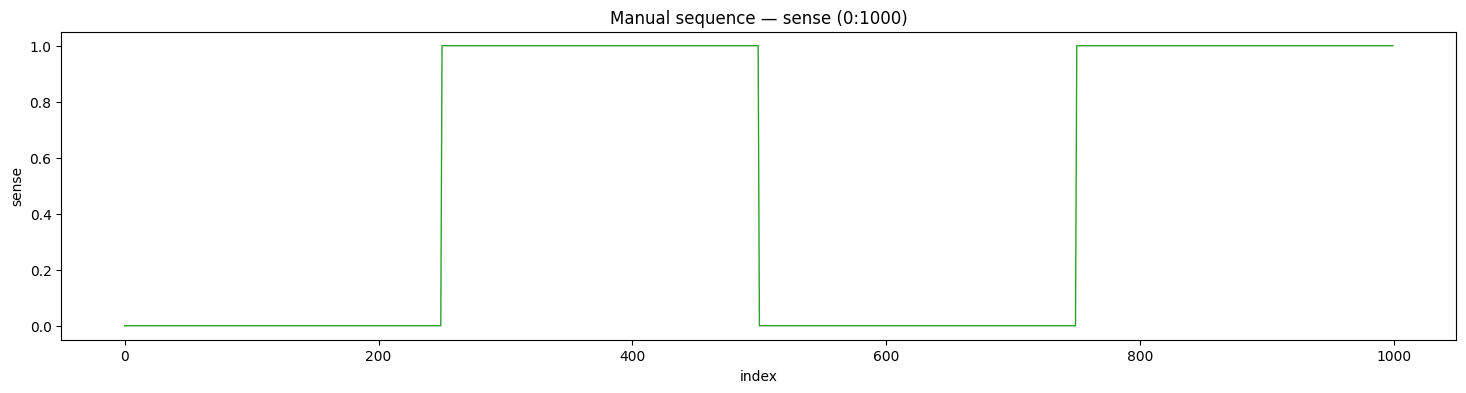

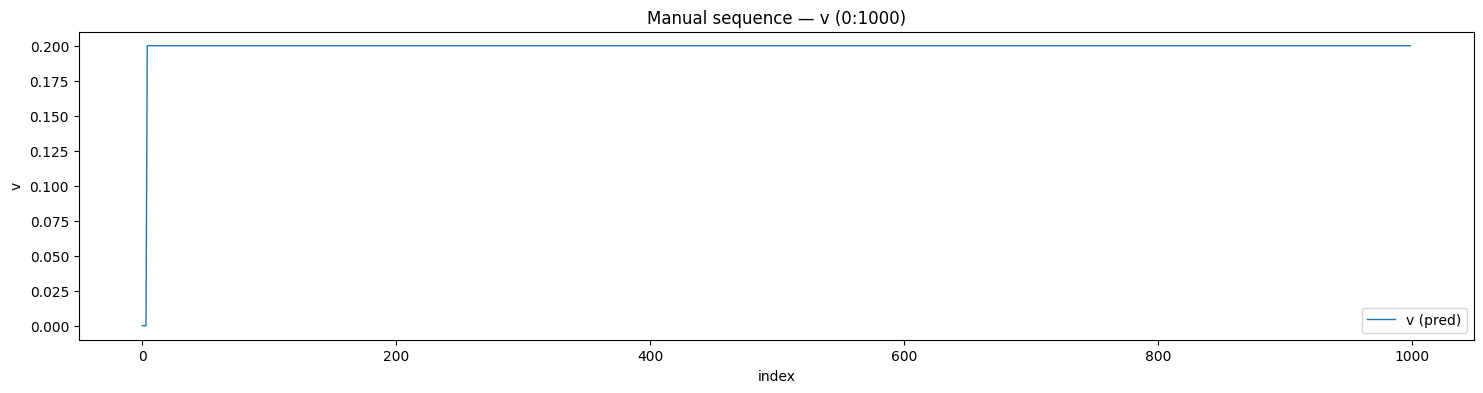

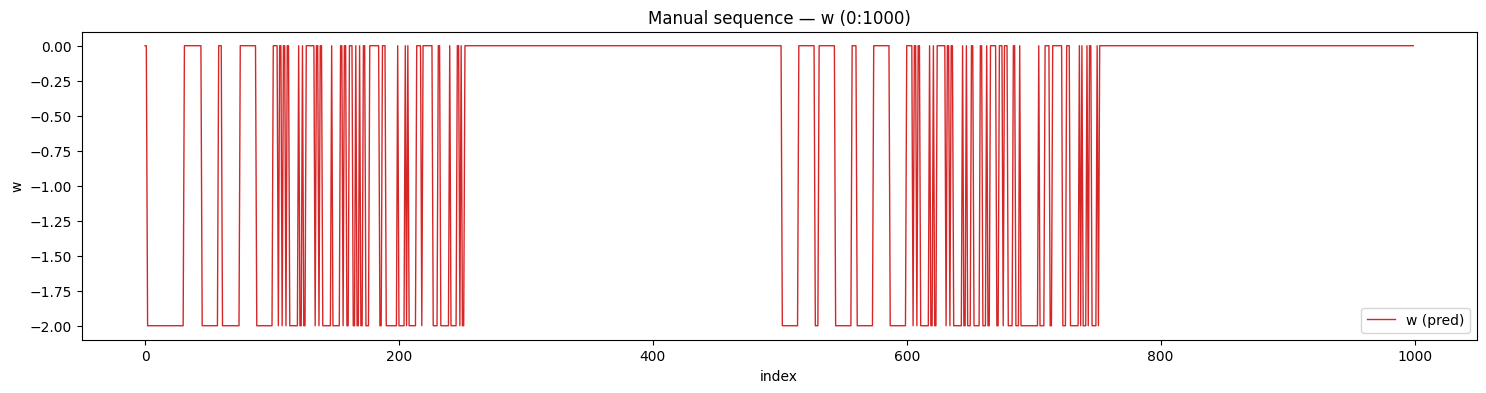

In [133]:
network = SNNNetwork(network_config)

warmup_sequence = [] # ([0]*3 + [1]*15)*10
for sensor_value in warmup_sequence:
    _ = run_processor(network, bool(sensor_value))

input_sequence = [0]*250 + [1]* 250 + [0]*250 + [1]* 550

# pattern = [0]*3 + [1]*15
# N = 1000
# input_sequence = (pattern * ((N // len(pattern)) + 1))[:N]

results = {'v': [], 'w': [], 'input': [], 's2': [], 's3': [], 's4': [], 's5': []}
for cycle, sensor_value in enumerate(input_sequence):
    v, w, out_counts = run_processor(network, bool(sensor_value))
    results['v'].append(v)
    results['w'].append(w)
    results['input'].append(sensor_value)
    results['s2'].append(out_counts[0])
    results['s3'].append(out_counts[1])
    results['s4'].append(out_counts[2])
    results['s5'].append(out_counts[3])


df_manual = pd.DataFrame(results).rename(columns={"input": "sense"})
# manual doesn't have true v/w, so treat v & w as "pred"
df_manual["v_pred"] = df_manual["v"]
df_manual["w_pred"] = df_manual["w"]

plot_snn_results(
    df_manual,
    x_col=None,
    sense_col="sense",
    v_true_col=None,
    w_true_col=None,
    v_pred_col="v_pred",
    w_pred_col="w_pred",
    t_start=0,
    t_end=1000,
    title_prefix="Manual sequence"
)


## Running with the inputs found from the agent_trajectories.xlsx file

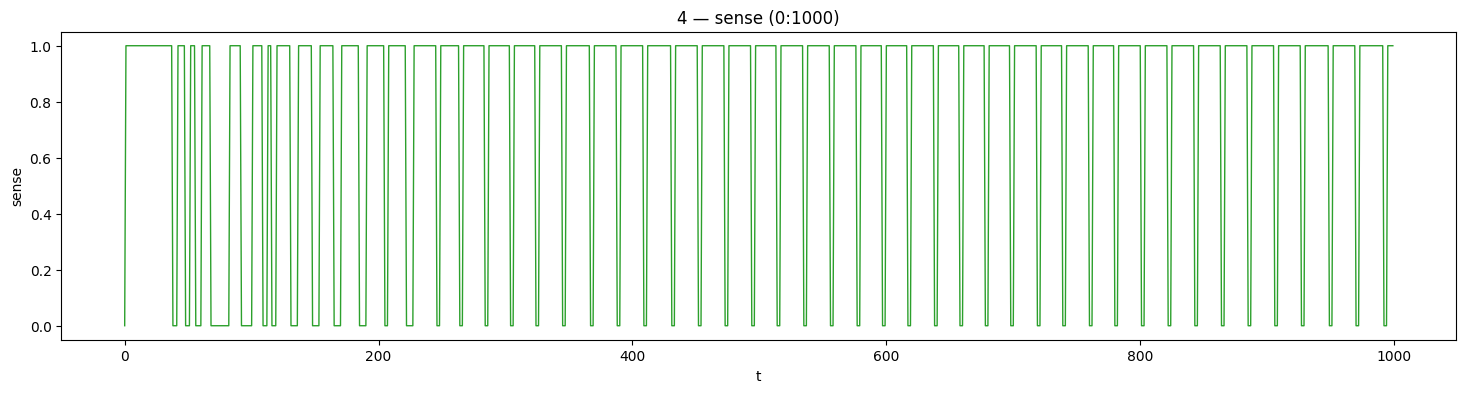

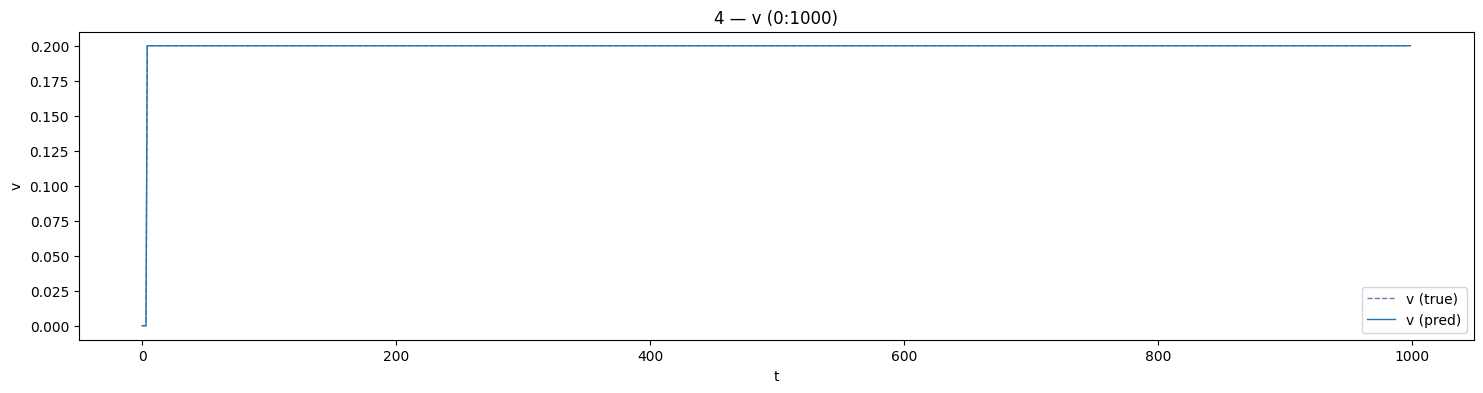

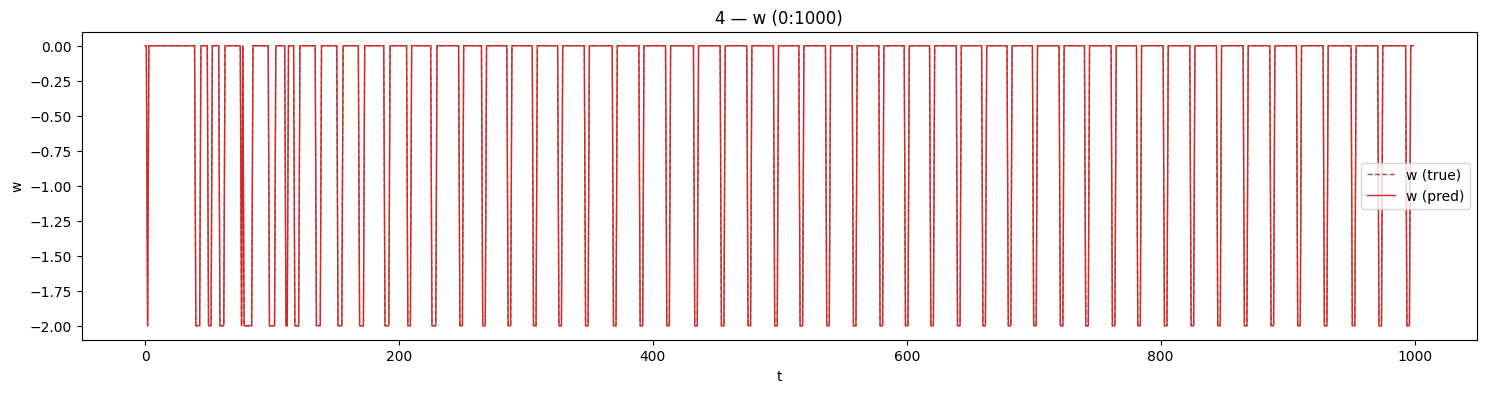

In [134]:
import numpy as np
import pandas as pd

xlsx_path = "results/agent_trajectories_cy_1000.xlsx"

NEURO_TPC = 1
EXTRA_TICKS = 5

WARMUP_SEQUENCE = [] #([0]*3 + [1]*15)*10

SENSE_COL = "sense"
V_COL = "v"
W_COL = "w"

def run_snn_on_sheet(df_sheet: pd.DataFrame, sheet_name: str):
    missing = [c for c in [SENSE_COL, V_COL, W_COL] if c not in df_sheet.columns]
    if missing:
        raise ValueError(f"Sheet '{sheet_name}' missing columns {missing}. Found: {list(df_sheet.columns)}")

    sense = df_sheet[SENSE_COL].astype(int).values
    v_true = df_sheet[V_COL].astype(float).values
    w_true = df_sheet[W_COL].astype(float).values

    # Fresh network per sheet (prevents state leakage)
    net = SNNNetwork(network_config)

    for s in WARMUP_SEQUENCE:
        _ = run_processor(net, bool(s), neuro_tpc=NEURO_TPC, extra_ticks=EXTRA_TICKS)

    v_pred = np.zeros_like(v_true, dtype=float)
    w_pred = np.zeros_like(w_true, dtype=float)
    s2 = np.zeros(len(sense), dtype=int)
    s3 = np.zeros(len(sense), dtype=int)
    s4 = np.zeros(len(sense), dtype=int)
    s5 = np.zeros(len(sense), dtype=int)

    for i, s in enumerate(sense):
        v, w, out_counts = run_processor(net, bool(s), neuro_tpc=NEURO_TPC, extra_ticks=EXTRA_TICKS)
        v_pred[i] = v
        w_pred[i] = w
        s2[i], s3[i], s4[i], s5[i] = out_counts

    out = df_sheet.copy()
    out["sheet"] = sheet_name
    out["v_pred"] = v_pred
    out["w_pred"] = w_pred
    out["s2"] = s2
    out["s3"] = s3
    out["s4"] = s4
    out["s5"] = s5

    v_match = np.isclose(out[V_COL].astype(float), out["v_pred"], atol=1e-6)
    w_match = np.isclose(out[W_COL].astype(float), out["w_pred"], atol=1e-6)
    out["v_match"] = v_match
    out["w_match"] = w_match
    out["vw_match"] = v_match & w_match

    return out

# Run on all sheets
xl = pd.ExcelFile(xlsx_path)
all_out = []
summary = []

for sh in xl.sheet_names:
    df_sh = pd.read_excel(xlsx_path, sheet_name=sh)
    out_sh = run_snn_on_sheet(df_sh, sh)
    all_out.append(out_sh)

    summary.append({
        "sheet": sh,
        "rows": len(out_sh),
        "vw_match_rate": float(out_sh["vw_match"].mean()),
        "v_match_rate": float(out_sh["v_match"].mean()),
        "w_match_rate": float(out_sh["w_match"].mean()),
        "mismatches": int((~out_sh["vw_match"]).sum())
    })

validated_snn = pd.concat(all_out, ignore_index=True)

dfp = validated_snn[validated_snn["sheet"] == sheet_to_plot].copy()

plot_snn_results(
    dfp,
    x_col="t" if "t" in dfp.columns else None,
    sense_col="sense",
    v_true_col="v",
    w_true_col="w",
    v_pred_col="v_pred",
    w_pred_col="w_pred",
    t_start=0,
    t_end=1000,
    title_prefix=f"{sheet_to_plot}"
)